In [1]:
import os
import shutil
import sys
import subprocess
import json
from pathlib import Path

In [2]:
# Load example params
params_path = Path("params_rover.json")  # change to the correct filename or absolute path
if not params_path.exists():
    raise FileNotFoundError(f"JSON file not found: {params_path}")

with params_path.open("r", encoding="utf-8") as f:
    params = json.load(f)

print("Loaded params:", params)

Loaded params: {'output_directory': 'output', 'iterations': 1, 'plant': 'cowpea', 'plots': {'mode': 'auto', 'location': 'Davis', 'year': 2023, 'crop_types': ['cowpea', 'bean', 'sorghum'], 'num_beds': {'sampling': 'uniform', 'min': 1, 'max': 1}, 'num_rows': {'sampling': 'uniform', 'min': 1, 'max': 1}, 'bed_spacing_x': {'sampling': 'constant', 'value': 1.0}, 'bed_spacing_y': {'sampling': 'constant', 'value': 1.0}, 'bed_height': 0.2, 'bed_width': 2, 'bed_length': 4, 'soil_color': [0.61, 0.58, 0.55], 'crops': [{'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': 0}, {'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': 0.75}, {'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': 1.5}, {'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': -0.75}, {'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': -1.5}]}, 'ground': {'size_x': {'sampling': 'constant', 'value': 2.5}, 'size_y': {'sampling': 'constant', 'value': 5.0}, 'use_obj_ground': False, 'obj_file_path': '../../../obj/di

In [33]:
# Load sample images from Agrowstitch result
import shutil
from PIL import Image
import re
from IPython.display import display
from ultralytics import SAM

class AmigaStitchDataset:
    def __init__(
        self,
        root=Path("/home/lion397/GEMINI/heesup/dataset/2025_Davis_Amiga/2025-06-17/Amiga/RGB/AgRowStitch_v0/"),
        program_path = "build_release/main",
        extensions=(".jpg", ".jpeg", ".png", ".tif"),
        transform=None,
        debug=False,
    ):
        self.root = Path(root)
        if not self.root.exists():
            raise FileNotFoundError(f"Root directory not found: {self.root}")
        self.transform = transform

        # filename pattern examples handled:
        # AgRowStitch_plot-12-3.jpg  or  AgRowStitch_plot-12.jpg
        pattern = re.compile(r"AgRowStitch[_-]plot[_-]?(?P<plot>[^-_\.]+)(?:[_-]?(?P<idx>\d+))?", re.IGNORECASE)

        self._files = []
        for p in sorted(self.root.iterdir()):
            if p.is_file() and p.suffix.lower() in extensions:
                m = pattern.search(p.name)
                plot = m.group("plot") if m else None
                idx = int(m.group("idx")) if (m and m.group("idx")) else None
                self._files.append({"path": p, "plot": plot, "idx": idx})

        if not self._files:
            raise RuntimeError(f"No images found in {self.root} matching pattern.")
    
        # Load SAM 2.1 model
        self.SAM_model = SAM("sam2.1_b.pt")

        self.plot_shortest_len = 1.2
        self.img_shape = []

        self.program_path = program_path
        self.debug = debug

    def __len__(self):
        return len(self._files)

    def __getitem__(self, i):
        entry = self._files[i]
        img = Image.open(entry["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, {"path": entry["path"], "plot": entry["plot"], "idx": entry["idx"]}

    def list_plot_ids(self):
        return sorted({e["plot"] for e in self._files if e["plot"] is not None})

    def localize_plants(self, idx=0, exg_thresh=None, min_size=10, show=True, use_sam=True):
        """
        Localize plants using ExG -> 1:1 box centers -> SAM refinement (optional) -> updated bbox.
        
        Args:
            idx: dataset index
            exg_thresh: ExG threshold for binary mask (None for auto Otsu)
            min_size: minimum blob area in pixels
            show: if True, display image with centers and bboxes overlayed
            use_sam: if True, use SAM for refinement; else, use ExG-based centers only
            
        Returns:
            list of dicts with keys: 'center', 'bbox', 'mask'
        """
        import numpy as np
        import cv2
        from skimage import measure
        import matplotlib.pyplot as plt
        import matplotlib.patches as patches
        
        # Step 1: Load image
        entry = self._files[idx]
        img = Image.open(entry["path"]).convert("RGB")
        img_np = np.array(img)
        self.img_shape = img_np.shape
        # Step 2: Compute ExG and binary mask
        r, g, b = img_np[..., 0], img_np[..., 1], img_np[..., 2]
        denom = (r + g + b).astype(np.float32) + 1e-6
        exg = np.clip((2.0 * g - r - b) / denom, -1, 1)
        
        # Apply Gaussian filtering to smooth the ExG image and connect nearby blobs
        exg_blurred = cv2.GaussianBlur(exg.astype(np.float32), (5, 5), 0)
        
        if exg_thresh is None:
            # Auto threshold with Otsu
            exg_norm = ((exg_blurred + 1) * 127.5).astype(np.uint8)
            thresh_val, bin_mask = cv2.threshold(exg_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            exg_thresh = (thresh_val / 127.5) - 1
            if self.debug:
                print(f"Auto threshold (Otsu): {exg_thresh:.3f}")
        else:
            # Manual threshold
            bin_mask = (exg_blurred > exg_thresh).astype(np.uint8) * 255
        
        # Enhanced morphological operations to reduce false positives
        kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        
        # Remove small noise
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN, kernel_small, iterations=2)
        # Close holes
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_CLOSE, kernel_large, iterations=2)
        # Final smoothing
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN, kernel_small)

        # Remove small components with stricter area filter
        labels = measure.label(bin_mask, connectivity=2)
        cleaned = np.zeros_like(bin_mask)
        for prop in measure.regionprops(labels):
            y1, x1, y2, x2 = prop.bbox
            h, w = y2 - y1, x2 - x1
            if max(h,w) >= min_size:
                coords = prop.coords
                cleaned[coords[:, 0], coords[:, 1]] = 255
        
        # Step 3: Split blobs into 1:1 boxes and extract centers
        labeled = measure.label(cleaned, connectivity=2)
        props = measure.regionprops(labeled)
        
        all_centers = []
        blob_info = []  # track which centers belong to which blob
        all_segmented_bboxes = []
        
        for prop in props:
            y1, x1, y2, x2 = prop.bbox
            h, w = y2 - y1, x2 - x1
            
            if w >= h:
                side = h
                n = int(np.ceil(w / side))
                seg_w = w//n
                for i in range(n):
                    seg_x1 = x1 + i * seg_w
                    seg_x2 = min(x1 + (i + 1) * seg_w, x2)
                    seg_y1 = y1
                    seg_y2 = y2
                    all_segmented_bboxes.append((seg_x1, seg_y1, seg_x2, seg_y2))
                    if 0:
                        cx = x1 + (i + 0.5) * w / n
                    else:
                        cx = (seg_x1 + seg_x2) / 2
                    cy = (y1 + y2) / 2.0
                    all_centers.append([cx, cy])
                    blob_info.append(prop.label)
        if self.debug:
            print("All centers:", all_centers)
            print("Blob info:", blob_info)
            
        if len(all_centers) == 0:
            print("No plant centers detected.")
            return []
        
        # Step 4: Refine with SAM or use ExG-based
        if use_sam:
            points = all_centers
            labels = [1] * len(points)  # all foreground points
            
            results = self.SAM_model(str(entry["path"]), points=points, labels=labels)
            
            # Step 5: Extract masks and update bboxes
            refined_plants = []
            
            for i, result in enumerate(results):
                if result.masks is None:
                    continue
                
                # Ultralytics returns masks in result.masks.data (tensor)
                for mask_tensor in result.masks.data:
                    mask = mask_tensor.cpu().numpy().astype(bool)
                    
                    # Update bbox from mask
                    ys, xs = np.where(mask)
                    if ys.size == 0:
                        continue
                        
                    bbox = (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max()))  # x1, y1, x2, y2
                    center = [(bbox[0] + bbox[2]) / 2.0, (bbox[1] + bbox[3]) / 2.0]
                    
                    refined_plants.append({
                        'center': center,
                        'bbox': bbox,
                        'mask': mask
                    })
        else:
            # Use ExG-based centers
            refined_plants = []
            # Use ExG-based centers
            refined_plants = []
            for i in range(len(all_centers)):
                seg_bbox = all_segmented_bboxes[i]
                prop_label = blob_info[i]
                full_mask = (labeled == prop_label).astype(bool)
                seg_x1, seg_y1, seg_x2, seg_y2 = seg_bbox
                
                # Extract only the selected region mask
                seg_mask = full_mask[seg_y1:seg_y2, seg_x1:seg_x2]
                
                # Get coordinates of mask pixels in the selected region
                ys, xs = np.where(seg_mask)
                
                if ys.size > 0:
                    # Calculate geometric mean (centroid) in original image coordinates
                    center = [np.mean(xs) + seg_x1, np.mean(ys) + seg_y1]
                    
                    # Calculate bbox based on the selected region mask in original coordinates
                    x1_adj = xs.min() + seg_x1
                    y1_adj = ys.min() + seg_y1
                    x2_adj = xs.max() + seg_x1
                    y2_adj = ys.max() + seg_y1
                    bbox = (x1_adj, y1_adj, x2_adj, y2_adj)
                    
                    # Create full-size mask with only selected region
                    mask_full = np.zeros_like(img_np[:, :, 0], dtype=bool)
                    mask_full[seg_y1:seg_y2, seg_x1:seg_x2] = seg_mask
                else:
                    # Fallback if no mask pixels found
                    center = [(seg_x1 + seg_x2) / 2.0, (seg_y1 + seg_y2) / 2.0]
                    bbox = seg_bbox
                    mask_full = np.zeros_like(img_np[:, :, 0], dtype=bool)
                
                refined_plants.append({
                    'center': center,
                    'bbox': bbox,
                    'mask': mask_full
                })
        
        # Convert to local coordinates (m)
        factor = self.plot_shortest_len / self.img_shape[0]
        for i in range(len(refined_plants)):
            center_scaled_x = (refined_plants[i]['center'][1] - self.img_shape[0]/2) * factor
            center_scaled_y = (refined_plants[i]['center'][0] - self.img_shape[1]/2) * factor
            refined_plants[i]['center_m'] = [center_scaled_x, center_scaled_y]


        # Step 6: Visualize if requested
        if show:
            fig, ax = plt.subplots(3, 1, figsize=(12, 12))
            # Top: ExG binary mask
            im1 = ax[0].imshow(exg)
            # cbar1 = fig.colorbar(im1, ax=ax[0])
            # cbar1.set_label('Color Scale for Subplot 1')
            

            # Top: ExG binary mask
            ax[1].imshow(cleaned, cmap='gray')
            ax[1].axis('off')
            ax[1].set_title(f'ExG Binary Mask (thresh={exg_thresh}, min_size={min_size})', fontsize=12)
            
            # Bottom: Detected plants with centers and bboxes
            ax[2].imshow(img_np)
            ax[2].axis('off')
            
            # # Overlay masks (SAM or ExG-based)
            # for plant in refined_plants:
            #     mask = plant['mask']
            #     ax[2].imshow(mask, alpha=0.3, cmap='Reds')  # Overlay mask with transparency
            
            # Draw all_centers (initial centers from ExG blobs)
            for cx, cy in all_centers:
                ax[2].plot(cx, cy, 'bo', markersize=8, markerfacecolor='none', markeredgewidth=2, label='Initial Centers' if all_centers.index([cx, cy]) == 0 else "")
            

            # Draw centers
            for plant in refined_plants:
                cx, cy = plant['center']
                ax[2].plot(cx, cy, 'r+', markersize=10, markeredgewidth=2, label='Refined Centers' if refined_plants.index(plant) == 0 else "")
            
            # Draw bboxes
            for plant in refined_plants:
                x1, y1, x2, y2 = plant['bbox']
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor='yellow', facecolor='none'
                )
                ax[2].add_patch(rect)
            if use_sam:
                ax[2].set_title(f'Detected {len(refined_plants)} plants - {entry["path"].name} (SAM: {use_sam})', fontsize=12)
            else:
                ax[2].set_title(f'Detected {len(refined_plants)} plants - {entry["path"].name}', fontsize=12)
            ax[2].legend()
            plt.tight_layout()
            plt.show()
        
        return refined_plants
    
    def generate_params(self, idx, refined_plants, params, crop_type="cowpea", 
                    bed=0, row=0, age=30):
        # Update json param
        crops = []
        for refined_plant in refined_plants:
            crop = {}
            crop['crop_type'] = crop_type
            crop['bed'] = bed
            crop['row'] = row
            crop['x'] = refined_plant['center_m'][0]
            crop['y'] = refined_plant['center_m'][1]

            crops.append(crop)

        params['plots']['mode'] = 'manual'
        params['plots']['location'] = 'helios'
        params['plots']['year'] = 2025
        params['plots']['crops'] = crops
        params['plantarchitecture']['initialize']['plant_age']['min'] = age
        params['plantarchitecture']['initialize']['plant_age']['max'] = age

        # Update ground size1
        factor = self.plot_shortest_len / self.img_shape[0]
        params['ground']['size_y']['value'] = self.img_shape[1] * factor
        params['ground']['size_x']['value'] = self.img_shape[1] * factor / 1920 * 1080
        params['ground']['use_obj_ground'] = True
        
        # To cover the entir field
        if 0:
            simulated_camera_height = params['ground']['size_x']['value'] / 2
            params['cameraproperties']['camera_height']['min'] = simulated_camera_height
            params['cameraproperties']['camera_height']['max'] = simulated_camera_height
            params['cameraproperties']["camera_resolution_x"]["value"] = self.img_shape[1]
            params['cameraproperties']["camera_resolution_y"]["value"] = self.img_shape[0]
        params['cameraproperties']["camera_positioning"]["center_plants"] = False

        # Save updated params
        # Specify the output file path (adjust as needed)
        entry = self._files[idx]
        output_path = entry["path"].with_suffix('.json')

        # Save the updated params to JSON file
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(params, f, indent=4)

        if self.debug:
            print(f"Updated params saved to {output_path}")

        return output_path

    def run_helios(self, params_path, output_path=None):
        # Generate image 
        # Construct the command
        if output_path is None:
            output_path = "output"
        output_name = str(params_path).split("/")[-1].split(".")[0]
        command = ""
        command += f"cd {self.program_path} && ./main " 
        # command += f"-h 1.0 -o {output_path} -seed {seed} -name {image_name} --xml -tile none -g"
        command += f"-h 1.0 -o {output_path} -n {output_name} -p {params_path} --xml"
        result = subprocess.run(command, shell=True, capture_output=True, text=True)


        # Check if the command was successful
        if result.returncode == 0:
            if self.debug:
                print("Command executed successfully")
                print(result.stdout)  # Print the standard output
            pass
        else:
            if self.debug:
                print(result.stdout)  # Print the standard output
                print(result.stderr)  # Print the error output
                # raise("Command failed")
            pass

from datetime import datetime
# Define the dates
dop = datetime(2025, 5, 27)
dap = datetime(2025, 6, 17) - dop



dataset_path = Path("/home/lion397/GEMINI/heesup/dataset/2025_Davis_Amiga/2025-06-17/Amiga/RGB/AgRowStitch_v0/")
helios_output_path = dataset_path / "helios_result"
# Create the directory if it doesn't exist
helios_output_path.mkdir(parents=True, exist_ok=True)


idx = 10
ds = AmigaStitchDataset(
    root=dataset_path,
    program_path="build_release")
print("Found", len(ds), "images. plot ids:", ds.list_plot_ids())
img, meta = ds[idx]
print(meta)
# img.show()
display(img)

results = ds.localize_plants(idx=idx, min_size=200, use_sam=False,show=True)
print(f"Found {len(results)} plants")
# print(results)

# Update params
generated_param_path = ds.generate_params(idx, results, params, age=dap.days)

# Run simulation on the output param
ds.run_helios(generated_param_path, helios_output_path)

# Copy the params file to helios path
# shutil.copyfile(generated_param_path, helios_output_path /)

RuntimeError: No images found in /home/lion397/GEMINI/heesup/dataset/2025_Davis_Amiga/2025-06-17/Amiga/RGB/AgRowStitch_v0 matching pattern.

Loaded params: {'output_directory': 'output', 'iterations': 1, 'plant': 'cowpea', 'plots': {'mode': 'auto', 'location': 'Davis', 'year': 2023, 'crop_types': ['cowpea', 'bean', 'sorghum'], 'num_beds': {'sampling': 'uniform', 'min': 1, 'max': 1}, 'num_rows': {'sampling': 'uniform', 'min': 1, 'max': 1}, 'bed_spacing_x': {'sampling': 'constant', 'value': 1.0}, 'bed_spacing_y': {'sampling': 'constant', 'value': 1.0}, 'bed_height': 0.2, 'bed_width': 2, 'bed_length': 4, 'soil_color': [0.61, 0.58, 0.55], 'crops': [{'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': 0}, {'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': 0.75}, {'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': 1.5}, {'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': -0.75}, {'crop_type': 'cowpea', 'bed': 0, 'row': 0, 'x': 0, 'y': -1.5}]}, 'ground': {'size_x': {'sampling': 'constant', 'value': 2.5}, 'size_y': {'sampling': 'constant', 'value': 5.0}, 'use_obj_ground': False, 'obj_file_path': '../../../obj/di

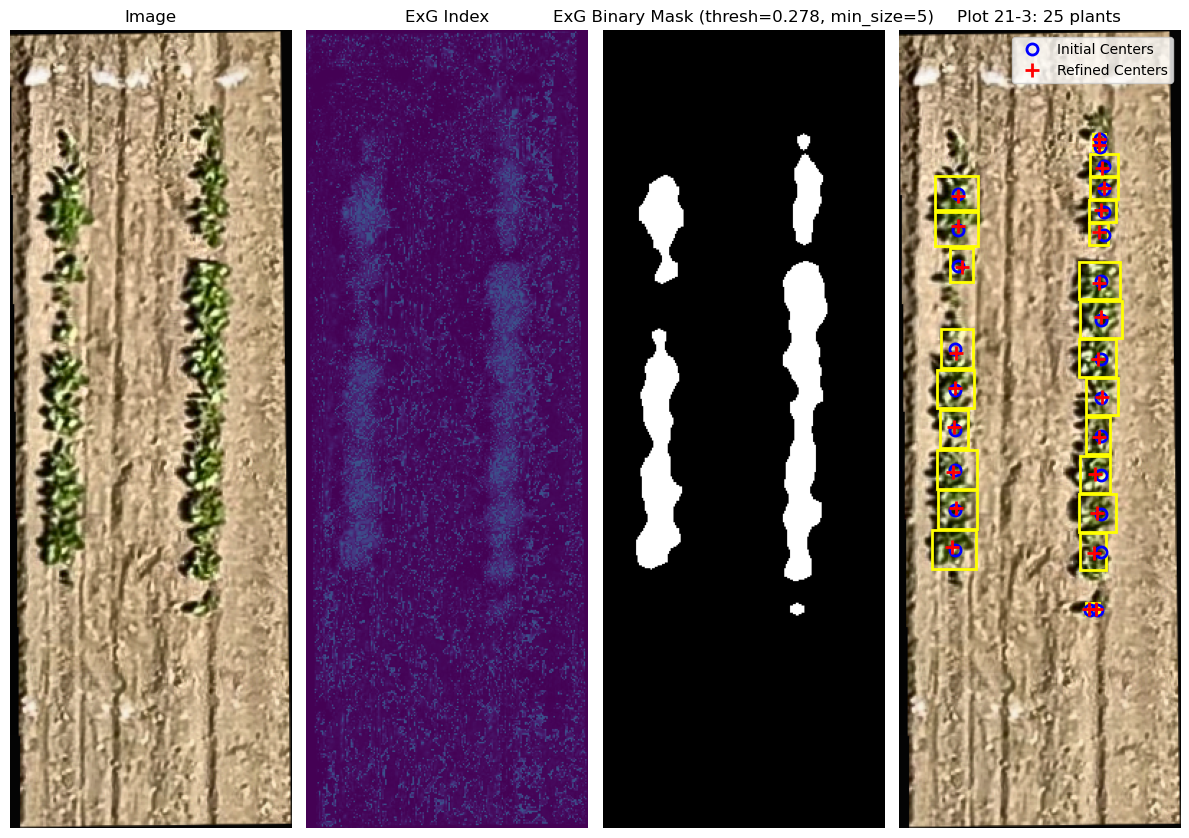

Updated params saved to /home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/plot_21_3.json


In [ ]:
import os
import shutil
import sys
import subprocess
import json
from pathlib import Path

# DroneOrthoDataset for processing georeferenced orthophotos
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import box, mapping
import numpy as np
from pathlib import Path
from PIL import Image
import json

# Load example params
params_path = Path("params_rover.json")  # change to the correct filename or absolute path
if not params_path.exists():
    raise FileNotFoundError(f"JSON file not found: {params_path}")

with params_path.open("r", encoding="utf-8") as f:
    params = json.load(f)

print("Loaded params:", params)

class DroneOrthoDataset:
    def __init__(
        self,
        ortho_path=Path("/path/to/orthophoto.tif"),
        dem_path=None,  # Add DEM path parameter
        geojson_path=Path("/path/to/plot_boundaries.geojson"),
        program_path="build_release/main",
        transform=None,
        debug=False,
        use_sam=False,
        target_crs="EPSG:32610",
    ):
        self.ortho_path = Path(ortho_path)
        self.dem_path = Path(dem_path) if dem_path else None
        self.geojson_path = Path(geojson_path)
        
        if not self.ortho_path.exists():
            raise FileNotFoundError(f"Orthophoto not found: {self.ortho_path}")
        if self.dem_path and not self.dem_path.exists():
            raise FileNotFoundError(f"DEM not found: {self.dem_path}")
        if not self.geojson_path.exists():
            raise FileNotFoundError(f"GeoJSON not found: {self.geojson_path}")
        
        self.transform = transform
        self.program_path = program_path
        self.debug = debug
        self.target_crs = target_crs
        
        # Load SAM 2.1 model
        if use_sam:
            from ultralytics import SAM
            self.SAM_model = SAM("sam2.1_b.pt")
        
        # Load orthophoto metadata
        with rasterio.open(self.ortho_path) as src:
            self.ortho_crs = src.crs
            self.ortho_transform = src.transform
            self.ortho_bounds = src.bounds
            self.ortho_shape = (src.height, src.width)
            
            if self.ortho_crs.is_geographic:
                if self.debug:
                    print(f"Original CRS is geographic ({self.ortho_crs}), will reproject to {target_crs}")
                self.needs_reprojection = True
                self.working_crs = target_crs
            else:
                self.needs_reprojection = False
                self.working_crs = self.ortho_crs
                
            if not self.needs_reprojection:
                self.pixel_size_x = abs(src.transform.a)
                self.pixel_size_y = abs(src.transform.e)
                self.pixel_size = (self.pixel_size_x + self.pixel_size_y) / 2
            else:
                from rasterio.warp import calculate_default_transform
                transform, width, height = calculate_default_transform(
                    src.crs, target_crs, src.width, src.height, *src.bounds
                )
                self.pixel_size_x = abs(transform.a)
                self.pixel_size_y = abs(transform.e)
                self.pixel_size = (self.pixel_size_x + self.pixel_size_y) / 2
            
            if self.debug:
                print(f"Orthophoto CRS: {self.ortho_crs}")
                print(f"Working CRS: {self.working_crs}")
                print(f"Pixel size: {self.pixel_size:.6f} m/pixel")
                print(f"Image dimensions: {self.ortho_shape}")
        
        # Load plot boundaries from GeoJSON
        self.plots_gdf = gpd.read_file(self.geojson_path)
        
        if self.plots_gdf.crs != self.working_crs:
            if self.debug:
                print(f"Reprojecting plots from {self.plots_gdf.crs} to {self.working_crs}")
            self.plots_gdf = self.plots_gdf.to_crs(self.working_crs)
        
        # Extract plot metadata
        self._files = []
        for idx, row in self.plots_gdf.iterrows():
            plot_info = {
                'idx': idx,
                'geometry': row.geometry,
                'bed': row.get('bed', row.get('column', idx)),
                'row': row.get('row', 0),
                'properties': dict(row.drop('geometry'))
            }
            self._files.append(plot_info)
        
        if not self._files:
            raise RuntimeError(f"No plots found in {self.geojson_path}")
        
        if self.debug:
            print(f"Loaded {len(self._files)} plots from GeoJSON")
    
    def __len__(self):
        return len(self._files)
    
    def __getitem__(self, i):
        """Extract and return cropped image for a specific plot"""
        from rasterio.warp import reproject, Resampling
        
        entry = self._files[i]
        
        # Crop orthophoto to plot boundary
        with rasterio.open(self.ortho_path) as src:
            if self.needs_reprojection:
                # First, reproject the geometry back to source CRS for masking
                geom_src_crs = gpd.GeoSeries([entry['geometry']], crs=self.working_crs).to_crs(src.crs)[0]
                geom = [mapping(geom_src_crs)]
                
                # Mask and crop
                out_image, out_transform = mask(src, geom, crop=True)
                
                # Now reproject the cropped image to target CRS
                # Calculate destination shape
                from rasterio.warp import calculate_default_transform
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    src.crs,
                    self.working_crs,
                    out_image.shape[2],
                    out_image.shape[1],
                    *rasterio.transform.array_bounds(out_image.shape[1], out_image.shape[2], out_transform)
                )
                
                # Create destination array
                dst_image = np.zeros((out_image.shape[0], dst_height, dst_width), dtype=out_image.dtype)
                
                # Reproject each band
                for i in range(out_image.shape[0]):
                    reproject(
                        source=out_image[i],
                        destination=dst_image[i],
                        src_transform=out_transform,
                        src_crs=src.crs,
                        dst_transform=dst_transform,
                        dst_crs=self.working_crs,
                        resampling=Resampling.bilinear
                    )
                
                out_image = dst_image
            else:
                # Original code - no reprojection needed
                geom = [mapping(entry['geometry'])]
                out_image, out_transform = mask(src, geom, crop=True)
            
            # Convert to HWC format
            out_image = np.transpose(out_image, (1, 2, 0))
            
            # Convert to PIL Image
            if out_image.shape[2] >= 3:
                img = Image.fromarray(out_image[:, :, :3].astype(np.uint8))
            else:
                img = Image.fromarray(out_image.astype(np.uint8))
        
        if self.transform:
            img = self.transform(img)
        
        return img, {
            'idx': entry['idx'],
            'bed': entry['bed'],
            'row': entry['row'],
            'geometry': entry['geometry'],
            'properties': entry['properties']
        }
    
    def list_plot_ids(self):
        """Return list of (bed, row) tuples"""
        return [(e['bed'], e['row']) for e in self._files]
        
    def localize_plants(self, idx=0, thresh=None, min_size=10, show=True, use_sam=True, histogram_norm=False):
        """
        Localize plants in a cropped plot using ExG -> SAM refinement.
        Similar to AmigaStitchDataset but works on cropped drone orthophoto.
        
        Args:
            idx: dataset index
            thresh: ExG threshold for binary mask (None for auto Otsu)
            min_size: minimum blob area in pixels
            show: if True, display image with centers and bboxes overlayed
            use_sam: if True, use SAM for refinement
            histogram_norm: if True, apply histogram equalization to improve contrast
            
        Returns:
            list of dicts with keys: 'center', 'bbox', 'mask', 'center_m'
        """
        import numpy as np
        import cv2
        from skimage import measure
        import matplotlib.pyplot as plt
        import matplotlib.patches as patches
        
        # Step 1: Load cropped image for this plot
        img, meta = self[idx]
        img_np = np.array(img)
        
        # Apply histogram normalization if requested
        if histogram_norm:
            # Convert to LAB color space for better histogram equalization
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            
            # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to L channel
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l_equalized = clahe.apply(l)
            
            # Merge channels and convert back to RGB
            lab_equalized = cv2.merge([l_equalized, a, b])
            img_np = cv2.cvtColor(lab_equalized, cv2.COLOR_LAB2RGB)
            
            if self.debug:
                print("Applied histogram normalization (CLAHE)")
        
        self.img_shape = img_np.shape
        
        # Get plot shortest dimension in meters
        entry = self._files[idx]
        geom = entry['geometry']
        bounds = geom.bounds  # (minx, miny, maxx, maxy) in CRS units (meters)
        plot_width_m = bounds[2] - bounds[0]
        plot_height_m = bounds[3] - bounds[1]
        plot_shortest_len = min(plot_width_m, plot_height_m)
        
        if self.debug:
            print(f"Plot dimensions: {plot_width_m:.2f}m x {plot_height_m:.2f}m")
            print(f"Plot shortest dimension: {plot_shortest_len:.2f}m")
        
        # Step 2: Compute ExG and binary mask
        r, g, b = img_np[..., 0], img_np[..., 1], img_np[..., 2]
        denom = (r + g + b).astype(np.float32) + 1e-6
        exg = np.clip((2.0 * g - r - b) / denom, -1, 1)
        
        # Apply Gaussian filtering
        exg_blurred = cv2.GaussianBlur(exg.astype(np.float32), (3, 3), 0)

        if thresh is None:
            # Auto threshold with Otsu
            exg_norm = ((exg_blurred + 1) * 127.5).astype(np.uint8)
            thresh_val, bin_mask = cv2.threshold(exg_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            thresh = (thresh_val / 127.5) - 1
            if self.debug:
                print(f"Auto threshold (Otsu): {thresh:.3f}")
        else:
            bin_mask = (exg_blurred > thresh).astype(np.uint8) * 255
        
        # Morphological operations
        kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN, kernel_small, iterations=2)
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_CLOSE, kernel_large, iterations=2)
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN, kernel_small)
        
        # Remove small components
        labels = measure.label(bin_mask, connectivity=2)
        cleaned = np.zeros_like(bin_mask)
        for prop in measure.regionprops(labels):
            y1, x1, y2, x2 = prop.bbox
            h, w = y2 - y1, x2 - x1
            if max(h, w) >= min_size:
                coords = prop.coords
                cleaned[coords[:, 0], coords[:, 1]] = 255
        
        # Step 3: Extract blob centers
        labeled = measure.label(cleaned, connectivity=2)
        props = measure.regionprops(labeled)
        
        all_centers = []
        blob_info = []
        all_segmented_bboxes = []
        
        for prop in props:
            y1, x1, y2, x2 = prop.bbox
            h, w = y2 - y1, x2 - x1
            
            if w >= h:
                side = h
                n = int(np.ceil(w / side))
                seg_w = w // n
                for i in range(n):
                    seg_x1 = x1 + i * seg_w
                    seg_x2 = min(x1 + (i + 1) * seg_w, x2)
                    seg_y1 = y1
                    seg_y2 = y2
                    all_segmented_bboxes.append((seg_x1, seg_y1, seg_x2, seg_y2))
                    cx = (seg_x1 + seg_x2) / 2
                    cy = (y1 + y2) / 2.0
                    all_centers.append([cx, cy])
                    blob_info.append(prop.label)
            else:
                # Handle vertical blobs (h > w) - split into vertical segments
                side = w
                n = int(np.ceil(h / side))
                seg_h = h // n
                for i in range(n):
                    seg_x1 = x1
                    seg_x2 = x2
                    seg_y1 = y1 + i * seg_h
                    seg_y2 = min(y1 + (i + 1) * seg_h, y2)
                    all_segmented_bboxes.append((seg_x1, seg_y1, seg_x2, seg_y2))
                    cx = (x1 + x2) / 2.0
                    cy = (seg_y1 + seg_y2) / 2
                    all_centers.append([cx, cy])
                    blob_info.append(prop.label)

        

        
        # Step 4: Refine with SAM or use ExG-based
        if use_sam:
            # Save temporary cropped image for SAM
            temp_path = self.ortho_path.parent / f"temp_plot_{idx}.jpg"
            img.save(temp_path)
            
            points = all_centers
            labels = [1] * len(points)
            
            results = self.SAM_model(str(temp_path), points=points, labels=labels)
            
            refined_plants = []
            for i, result in enumerate(results):
                if result.masks is None:
                    continue
                
                for mask_tensor in result.masks.data:
                    mask = mask_tensor.cpu().numpy().astype(bool)
                    
                    ys, xs = np.where(mask)
                    if ys.size == 0:
                        continue
                    
                    bbox = (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max()))
                    center = [(bbox[0] + bbox[2]) / 2.0, (bbox[1] + bbox[3]) / 2.0]
                    
                    refined_plants.append({
                        'center': center,
                        'bbox': bbox,
                        'mask': mask
                    })
            
            # Clean up temp file
            temp_path.unlink()
        else:
            # Use ExG-based centers
            refined_plants = []
            for i in range(len(all_centers)):
                seg_bbox = all_segmented_bboxes[i]
                prop_label = blob_info[i]
                full_mask = (labeled == prop_label).astype(bool)
                seg_x1, seg_y1, seg_x2, seg_y2 = seg_bbox
                
                seg_mask = full_mask[seg_y1:seg_y2, seg_x1:seg_x2]
                ys, xs = np.where(seg_mask)
                
                if ys.size > 0:
                    center = [np.mean(xs) + seg_x1, np.mean(ys) + seg_y1]
                    x1_adj = xs.min() + seg_x1
                    y1_adj = ys.min() + seg_y1
                    x2_adj = xs.max() + seg_x1
                    y2_adj = ys.max() + seg_y1
                    bbox = (x1_adj, y1_adj, x2_adj, y2_adj)
                    
                    mask_full = np.zeros_like(img_np[:, :, 0], dtype=bool)
                    mask_full[seg_y1:seg_y2, seg_x1:seg_x2] = seg_mask
                else:
                    center = [(seg_x1 + seg_x2) / 2.0, (seg_y1 + seg_y2) / 2.0]
                    bbox = seg_bbox
                    mask_full = np.zeros_like(img_np[:, :, 0], dtype=bool)
                
                refined_plants.append({
                    'center': center,
                    'bbox': bbox,
                    'mask': mask_full
                })
        
        # Convert to local coordinates (meters) relative to plot center
        factor = self.pixel_size  # meters per pixel
        plot_center_x = self.img_shape[1] / 2
        plot_center_y = self.img_shape[0] / 2
        
        for plant in refined_plants:
            # Convert pixel coordinates to meters, centered at plot origin
            center_scaled_x = (plant['center'][1] - plot_center_y) * factor
            center_scaled_y = (plant['center'][0] - plot_center_x) * factor
            plant['center_m'] = [center_scaled_x, center_scaled_y]
        
        # Step 5: Visualize if requested
        if show:
            fig, ax = plt.subplots(1, 4, figsize=(12, 12))
            
            ax[0].imshow(img_np)
            ax[0].set_title('Image', fontsize=12)
            ax[0].axis('off')

            ax[1].imshow(exg, vmin=0, vmax=4)
            ax[1].set_title('ExG Index', fontsize=12)
            ax[1].axis('off')
            
            ax[2].imshow(cleaned, cmap='gray')
            ax[2].axis('off')
            ax[2].set_title(f'ExG Binary Mask (thresh={thresh:.3f}, min_size={min_size})', fontsize=12)
            
            ax[3].imshow(img_np)
            ax[3].axis('off')
            
            # Draw initial centers
            for i, (cx, cy) in enumerate(all_centers):
                ax[3].plot(cx, cy, 'bo', markersize=8, markerfacecolor='none', 
                          markeredgewidth=2, label='Initial Centers' if i == 0 else "")
            
            # Draw refined centers and bboxes
            for i, plant in enumerate(refined_plants):
                cx, cy = plant['center']
                ax[3].plot(cx, cy, 'r+', markersize=10, markeredgewidth=2, 
                          label='Refined Centers' if i == 0 else "")
                
                x1, y1, x2, y2 = plant['bbox']
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor='yellow', facecolor='none'
                )
                ax[3].add_patch(rect)
            
            title = f"Plot {meta['bed']}-{meta['row']}: {len(refined_plants)} plants"
            if use_sam:
                title += " (SAM)"
            ax[3].set_title(title, fontsize=12)
            ax[3].legend()
            plt.tight_layout()
            plt.show()
        
        if len(all_centers) == 0:
            print("No plant centers detected.")
            return []
        
        return refined_plants
    
    def crop_dem_to_plot(self, idx, output_dir=None, match_rgb_resolution=True):
        """
        Crop DEM to plot boundary and save as TIFF
        
        Args:
            idx: dataset index
            output_dir: Output directory for cropped DEM (default: ortho_path parent / "dem_crops")
            match_rgb_resolution: If True, resize DEM to match RGB image resolution
            
        Returns:
            Path to cropped DEM TIFF file
        """
        import matplotlib.pyplot as plt
        import cv2
        
        if self.dem_path is None:
            raise ValueError("No DEM path provided during initialization")
        
        if output_dir is None:
            output_dir = self.ortho_path.parent / "dem_crops"
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        entry = self._files[idx]
        
        from rasterio.warp import reproject, Resampling
        
        # First, get the RGB image dimensions for this plot
        img, meta = self[idx]
        rgb_height, rgb_width = np.array(img).shape[:2]
        
        if self.debug:
            print(f"Target RGB resolution: {rgb_width}x{rgb_height} pixels")
        
        # Crop DEM to plot boundary
        with rasterio.open(self.dem_path) as src:
            if self.needs_reprojection or src.crs != self.working_crs:
                # Reproject geometry to source CRS for masking
                geom_src_crs = gpd.GeoSeries([entry['geometry']], crs=self.working_crs).to_crs(src.crs)[0]
                geom = [mapping(geom_src_crs)]
                
                # Mask and crop
                out_dem, out_transform = mask(src, geom, crop=True, filled=False)
                
                # Calculate mean of valid elevation values
                valid_mask = out_dem != src.nodata if src.nodata is not None else ~np.isnan(out_dem)
                if np.any(valid_mask):
                    mean_elevation = np.mean(out_dem[valid_mask])
                else:
                    mean_elevation = 0.0
                
                # Reset nodata values to mean elevation
                if src.nodata is not None:
                    out_dem[out_dem == src.nodata] = mean_elevation
                # Also handle NaN values
                out_dem = np.nan_to_num(out_dem, nan=mean_elevation)
                
                # Reproject to working CRS if needed
                if src.crs != self.working_crs:
                    from rasterio.warp import calculate_default_transform
                    dst_transform, dst_width, dst_height = calculate_default_transform(
                        src.crs,
                        self.working_crs,
                        out_dem.shape[2],
                        out_dem.shape[1],
                        *rasterio.transform.array_bounds(out_dem.shape[1], out_dem.shape[2], out_transform)
                    )
                    
                    dst_dem = np.zeros((1, dst_height, dst_width), dtype=out_dem.dtype)
                    
                    reproject(
                        source=out_dem[0],
                        destination=dst_dem[0],
                        src_transform=out_transform,
                        src_crs=src.crs,
                        dst_transform=dst_transform,
                        dst_crs=self.working_crs,
                        resampling=Resampling.bilinear
                    )
                    
                    out_dem = dst_dem
                    out_transform = dst_transform
            else:
                # No reprojection needed
                geom = [mapping(entry['geometry'])]
                out_dem, out_transform = mask(src, geom, crop=True, filled=False)
                
                # Calculate mean of valid elevation values
                valid_mask = out_dem != src.nodata if src.nodata is not None else ~np.isnan(out_dem)
                if np.any(valid_mask):
                    mean_elevation = np.mean(out_dem[valid_mask])
                else:
                    mean_elevation = 0.0
                
                # Reset nodata values to mean elevation
                if src.nodata is not None:
                    out_dem[out_dem == src.nodata] = mean_elevation
                # Also handle NaN values
                out_dem = np.nan_to_num(out_dem, nan=mean_elevation)
            
            # Resize DEM to match RGB resolution
            if match_rgb_resolution:
                original_shape = (out_dem.shape[1], out_dem.shape[2])
                
                if self.debug:
                    print(f"Original DEM shape: {original_shape[1]}x{original_shape[0]} pixels")
                
                # Extract the elevation data
                dem_data = out_dem[0]
                
                # Resize using OpenCV for high-quality interpolation
                resized_dem = cv2.resize(
                    dem_data.astype(np.float32), 
                    (rgb_width, rgb_height),
                    interpolation=cv2.INTER_CUBIC
                )
                
                # Update the DEM array
                out_dem = resized_dem[np.newaxis, :, :]
                
                # Calculate new pixel size
                geom = entry['geometry']
                bounds = geom.bounds
                plot_width_m = bounds[2] - bounds[0]
                plot_height_m = bounds[3] - bounds[1]
                
                new_pixel_size_x = plot_width_m / rgb_width
                new_pixel_size_y = plot_height_m / rgb_height
                
                # Update transform for the new resolution
                from rasterio.transform import from_bounds
                out_transform = from_bounds(
                    bounds[0], bounds[1], bounds[2], bounds[3],
                    rgb_width, rgb_height
                )
                
                if self.debug:
                    print(f"Resized DEM to match RGB: {rgb_width}x{rgb_height} pixels")
                    print(f"New pixel size: {new_pixel_size_x:.6f} x {new_pixel_size_y:.6f} m")
            
            # Save cropped DEM
            cropped_dem_path = output_dir / f"plot_{entry['bed']}_{entry['row']}_dem.tif"
            
            profile = src.profile.copy()
            profile.update({
                'height': out_dem.shape[1],
                'width': out_dem.shape[2],
                'transform': out_transform,
                'crs': self.working_crs
            })
            
            with rasterio.open(cropped_dem_path, 'w', **profile) as dst:
                dst.write(out_dem)
        
            # Visualize if self.debug is true
            if self.debug:
                # Extract elevation data
                dem_data = out_dem[0].astype(np.float32)
                
                # Handle nodata values
                nodata = profile.get('nodata')
                if nodata is not None:
                    dem_data[dem_data == nodata] = np.nan
                
                valid_mask = ~np.isnan(dem_data)
                valid_data = dem_data[valid_mask]
                
                # Create visualization
                fig, axes = plt.subplots(2, 2, figsize=(14, 12))
                
                # 1. Original DEM with colorbar
                im0 = axes[0, 0].imshow(dem_data, cmap='terrain', vmin=valid_data.min(), vmax=valid_data.max())
                axes[0, 0].set_title(
                    f'Cropped DEM - Plot {entry["bed"]}-{entry["row"]}\n'
                    f'Range: {valid_data.min():.2f} to {valid_data.max():.2f} m',
                    fontsize=12
                )
                axes[0, 0].set_xlabel('X Pixels')
                axes[0, 0].set_ylabel('Y Pixels')
                cbar0 = plt.colorbar(im0, ax=axes[0, 0], label='Elevation (m)')
                
                # 2. DEM with resolution info
                im1 = axes[0, 1].imshow(dem_data, cmap='gray', vmin=valid_data.min(), vmax=valid_data.max())
                axes[0, 1].set_title(
                    f'DEM Size: {dem_data.shape[1]}x{dem_data.shape[0]} pixels\n'
                    f'RGB Size: {rgb_width}x{rgb_height} pixels\n'
                    f'CRS: {self.working_crs}',
                    fontsize=12
                )
                axes[0, 1].set_xlabel('X Pixels')
                axes[0, 1].set_ylabel('Y Pixels')
                cbar1 = plt.colorbar(im1, ax=axes[0, 1], label='Elevation (m)')
                
                # 3. Shaded relief map
                from matplotlib.colors import LightSource
                import matplotlib.cm as cm
                ls = LightSource(azdeg=315, altdeg=45)
                shaded = ls.shade(dem_data, cmap=cm.gist_earth, vert_exag=0.1,
                                vmin=valid_data.min(), vmax=valid_data.max())
                im2 = axes[1, 0].imshow(shaded)
                axes[1, 0].set_title('Shaded Relief', fontsize=12)
                axes[1, 0].set_xlabel('X Pixels')
                axes[1, 0].set_ylabel('Y Pixels')
                axes[1, 0].axis('off')
                
                # 4. Elevation histogram
                axes[1, 1].hist(valid_data.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
                axes[1, 1].axvline(valid_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {valid_data.mean():.2f}')
                axes[1, 1].axvline(np.median(valid_data), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(valid_data):.2f}')
                axes[1, 1].set_title('Elevation Distribution', fontsize=12)
                axes[1, 1].set_xlabel('Elevation (m)')
                axes[1, 1].set_ylabel('Frequency')
                axes[1, 1].legend()
                axes[1, 1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                
                # Save visualization
                viz_path = output_dir / f"plot_{entry['bed']}_{entry['row']}_dem_viz.png"
                plt.savefig(viz_path, dpi=150, bbox_inches='tight')
                
                if self.debug:
                    print(f"\n=== DEM Cropping Report ===")
                    print(f"Plot: {entry['bed']}-{entry['row']}")
                    print(f"DEM Resolution: {dem_data.shape[1]}x{dem_data.shape[0]} pixels")
                    print(f"RGB Resolution: {rgb_width}x{rgb_height} pixels")
                    print(f"Resolution Match: {'Yes' if dem_data.shape[1] == rgb_width and dem_data.shape[0] == rgb_height else 'No'}")
                    print(f"Elevation Statistics:")
                    print(f"  Min: {valid_data.min():.2f} m")
                    print(f"  Max: {valid_data.max():.2f} m")
                    print(f"  Mean: {valid_data.mean():.2f} m")
                    print(f"  Std Dev: {valid_data.std():.2f} m")
                    print(f"  Median: {np.median(valid_data):.2f} m")
                    print(f"  Range: {valid_data.max() - valid_data.min():.2f} m")
                    print(f"Valid pixels: {np.sum(valid_mask)} / {dem_data.size}")
                    print(f"DEM saved to: {cropped_dem_path}")
                    print(f"Visualization saved to: {viz_path}\n")
                
                plt.close()
        
        return cropped_dem_path
    
    def dem_to_obj(self, dem_path, obj_path=None, scale_z=1.0, subsample=1, normalize=True):
        """
        Convert a Digital Elevation Model (DEM) TIFF to an OBJ file with proper normalization
        
        Args:
            dem_path: Path to DEM TIFF file
            obj_path: Output OBJ file path (default: dem_path with .obj extension)
            scale_z: Scale factor for Z/elevation values
            subsample: Subsample factor to reduce mesh density (1=full res, 2=half, etc.)
            normalize: If True, normalize elevations to 0-1 range and shift to ground level
            visualize: If True, show elevation visualization
        
        Returns:
            Path to generated OBJ file
        """
        import matplotlib.pyplot as plt
        
        dem_path = Path(dem_path)
        
        if obj_path is None:
            obj_path = dem_path.with_suffix('.obj')
        else:
            obj_path = Path(obj_path)
        
        # Read DEM data
        with rasterio.open(dem_path) as src:
            dem_data = src.read(1).astype(np.float32)
            height, width = dem_data.shape
            transform = src.transform
            scale_xy = abs(transform.a)
            nodata = src.nodata
        
        original_dem = dem_data.copy()
        
        # Handle nodata values first
        if nodata is not None:
            if not np.isnan(nodata):
                dem_data[dem_data == nodata] = np.nan
        
        # Replace NaN with mean elevation
        valid_mask = ~np.isnan(dem_data)
        if not np.all(valid_mask):
            if np.any(valid_mask):
                mean_elevation = np.nanmean(dem_data)
                dem_data[~valid_mask] = mean_elevation
            else:
                print("Warning: All DEM values are NaN, using 0")
                dem_data = np.zeros_like(dem_data)
        
        if self.debug:
            print(f"DEM Statistics (before processing):")
            print(f"  Min: {original_dem[valid_mask].min():.2f}")
            print(f"  Max: {original_dem[valid_mask].max():.2f}")
            print(f"  Mean: {original_dem[valid_mask].mean():.2f}")
            print(f"  Std: {original_dem[valid_mask].std():.2f}")
        
        # Normalize elevations
        if normalize:
            dem_min = dem_data.min()
            dem_max = dem_data.max()
            dem_range = dem_max - dem_min
            
            if dem_range > 0:
                # Normalize to 0-1 range
                dem_normalized = (dem_data - dem_min) / dem_range
            else:
                dem_normalized = np.zeros_like(dem_data)
            
            if self.debug:
                print(f"\nDEM Normalized Statistics:")
                print(f"  Min: {dem_normalized.min():.6f}")
                print(f"  Max: {dem_normalized.max():.6f}")
                print(f"  Mean: {dem_normalized.mean():.6f}")
        else:
            dem_normalized = dem_data
        
        # Subsample if requested
        if subsample > 1:
            dem_normalized = dem_normalized[::subsample, ::subsample]
            height, width = dem_normalized.shape
            scale_xy *= subsample
            
            if self.debug:
                print(f"\nSubsampled to: {width}x{height} pixels")
        
        if self.debug:
            print(f"Generating OBJ from DEM: {width}x{height} pixels")
            print(f"Scale XY: {scale_xy:.6f}, Scale Z: {scale_z:.6f}")
        
        # Write OBJ file
        vertex_count = 0
        with open(obj_path, 'w') as f:
            f.write(f"# OBJ file generated from DEM: {dem_path.name}\n")
            f.write(f"# Resolution: {width}x{height}\n")
            f.write(f"# Original elevation range: {original_dem[valid_mask].min():.2f} to {original_dem[valid_mask].max():.2f}\n")
            f.write(f"# Scale XY: {scale_xy:.6f}, Scale Z: {scale_z:.6f}\n")
            f.write(f"# Normalized: {normalize}\n\n")
            
            # Write vertices
            f.write("# Vertices\n")
            for y in range(height):
                for x in range(width):
                    x_coord = (x - width / 2) * scale_xy
                    y_coord = (y - height / 2) * scale_xy
                    z_coord = dem_normalized[y, x] * scale_z
                    f.write(f"v {x_coord:.6f} {y_coord:.6f} {z_coord:.6f}\n")
                    vertex_count += 1
            
            # Write texture coordinates
            f.write("\n# Texture coordinates\n")
            for y in range(height):
                for x in range(width):
                    u = x / (width - 1) if width > 1 else 0.0
                    v = 1.0 - (y / (height - 1)) if height > 1 else 0.0
                    f.write(f"vt {u:.6f} {v:.6f}\n")
            
            # Write faces (triangles)
            f.write("\n# Faces\n")
            face_count = 0
            for y in range(height - 1):
                for x in range(width - 1):
                    # Vertex indices (1-based in OBJ format)
                    v1 = y * width + x + 1
                    v2 = y * width + (x + 1) + 1
                    v3 = (y + 1) * width + x + 1
                    v4 = (y + 1) * width + (x + 1) + 1
                    
                    # Two triangles per quad with texture coordinates
                    f.write(f"f {v1}/{v1} {v2}/{v2} {v3}/{v3}\n")
                    f.write(f"f {v2}/{v2} {v4}/{v4} {v3}/{v3}\n")
                    face_count += 2
        
        if self.debug:
            print(f"OBJ file created successfully:")
            print(f"  Vertices: {vertex_count}")
            print(f"  Faces: {face_count}")
            print(f"  Saved to: {obj_path}")
        
        return obj_path
    
    def generate_ground_obj_for_plot(self, idx, output_dir=None, scale_z=1.0, subsample=2):
        """
        Generate DEM-based ground OBJ file for a specific plot
        
        Args:
            idx: Plot index
            output_dir: Output directory for OBJ files (default: ortho_path parent / "ground_meshes")
            scale_z: Scale factor for elevation
            subsample: Subsample factor to reduce mesh density
            
        Returns:
            Path to generated OBJ file
        """
        if self.dem_path is None:
            if self.debug:
                print("No DEM provided, skipping ground mesh generation")
            return None
        
        if output_dir is None:
            output_dir = self.ortho_path.parent / "ground_meshes"
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Crop DEM to plot
        cropped_dem_path = self.crop_dem_to_plot(idx, output_dir.parent / "dem_crops")
        
        # Convert to OBJ
        entry = self._files[idx]
        obj_path = output_dir / f"plot_{entry['bed']}_{entry['row']}_ground.obj"
        
        self.dem_to_obj(cropped_dem_path, obj_path, scale_z=scale_z, subsample=subsample)
        
        return obj_path
    
    def generate_params(self, idx, refined_plants, params, crop_type="cowpea", age=30, 
                       use_dem_ground=True, dem_scale_z=1.0, dem_subsample=2):
        """Generate Helios parameters for a cropped plot"""
        entry = self._files[idx]
        
        # Update json param
        crops = []
        for refined_plant in refined_plants:
            crop = {}
            crop['crop_type'] = crop_type
            if 0:
                crop['bed'] = entry['bed']
                crop['row'] = entry['row']
            else:
                # Hardcode to bed and row 0
                crop['bed'] = 0
                crop['row'] = 0

            if 0:
                # Original
                crop['x'] = refined_plant['center_m'][0]
                crop['y'] = refined_plant['center_m'][1]
            else:
                # Rotate 90
                crop['x'] = refined_plant['center_m'][1]
                crop['y'] = -refined_plant['center_m'][0]
            crops.append(crop)
        
        params['plots']['mode'] = 'manual'
        params['plots']['location'] = 'drone_ortho'
        params['plots']['year'] = 2025
        params['plots']['crops'] = crops
        params['plantarchitecture']['initialize']['plant_age']['min'] = age
        params['plantarchitecture']['initialize']['plant_age']['max'] = age
        

        # To cover the entir field
        if 0:
            simulated_camera_height = params['ground']['size_x']['value'] / 2
            params['cameraproperties']['camera_height']['min'] = simulated_camera_height
            params['cameraproperties']['camera_height']['max'] = simulated_camera_height
            params['cameraproperties']["camera_resolution_x"]["value"] = self.img_shape[1]
            params['cameraproperties']["camera_resolution_y"]["value"] = self.img_shape[0]
        params['cameraproperties']["camera_positioning"]["center_plants"] = False

        # Update ground size based on plot dimensions
        geom = entry['geometry']
        bounds = geom.bounds
        plot_width_m = bounds[2] - bounds[0]
        plot_height_m = bounds[3] - bounds[1]
        
        # Update ground size
        params['ground']['size_x']['value'] = plot_width_m
        params['ground']['size_y']['value'] = plot_height_m / 1920 * 1080
        
        # Generate DEM-based ground OBJ if available
        if use_dem_ground and self.dem_path:
            obj_path = self.generate_ground_obj_for_plot(
                idx, 
                scale_z=dem_scale_z, 
                subsample=dem_subsample
            )
            if obj_path:
                params['ground']['use_obj_ground'] = True
                params['ground']['obj_file_path'] = str(obj_path)
                if self.debug:
                    print(f"Using DEM-based ground mesh: {obj_path}")
        else:
            params['ground']['use_obj_ground'] = True
        params['cameraproperties']["camera_positioning"]["center_plants"] = False
        
        # Save updated params
        output_path = self.ortho_path.parent / f"plot_{entry['bed']}_{entry['row']}.json"
        
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(params, f, indent=4)
        
        if self.debug:
            print(f"Updated params saved to {output_path}")
    

        return output_path
    
    def run_helios(self, params_path, output_path=None, show=False):
        """Run Helios simulation"""
        if output_path is None:
            output_path = "output"
        output_name = str(params_path).split("/")[-1].split(".")[0]
        command = f"cd {self.program_path} && ./main -h 1.0 -o {output_path} -n {output_name} -p {params_path} --xml"
        result = subprocess.run(command, shell=True, capture_output=True, text=True)
        
        if result.returncode == 0:
            if self.debug:
                print("Command executed successfully")
                print(result.stdout)
        else:
            if self.debug:
                print(result.stdout)
                print(result.stderr)

        # Display generated image
        

from datetime import datetime
import re
# Define the planting date
dop = datetime(2025, 5, 27)

ortho_path = "/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-RGB.tif"

# Parse date from ortho_path using regex to find YYYY-MM-DD pattern
date_pattern = r'(\d{4})-(\d{2})-(\d{2})'
match = re.search(date_pattern, ortho_path)

if match:
    year, month, day = match.groups()
    ortho_date = datetime(int(year), int(month), int(day))
    dap = (ortho_date - dop).days
    print(f"Parsed ortho date: {ortho_date.strftime('%Y-%m-%d')}")
    print(f"Days after planting (DAP): {dap}")
else:
    # Fallback to manual calculation if parsing fails
    print("Warning: Could not parse date from ortho_path, using manual DAP")
    dap = (datetime(2025, 6, 17) - dop).days

ortho_path="/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-RGB.tif"
dem_path="/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-DEM.tif"
drone_ds = DroneOrthoDataset(
    ortho_path=Path(ortho_path),
    dem_path=Path(dem_path),  # Add DEM path
    #ortho_path=Path("/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-17/Drone-5m/GOPRO/2025-06-17-RGB.tif"),
    geojson_path=Path("/home/lion397/GEMINI/heesup/dataset/2025_Davis/Plot-Boundary-WGS84.geojson"),
    program_path="build_release",
    use_sam=True,
    debug=True
)

# Process single plot
idx = 100
img, meta = drone_ds[idx]
results = drone_ds.localize_plants(idx=idx, min_size=5, histogram_norm=True, use_sam=False, show=True)
params_path = drone_ds.generate_params(
    idx, 
    results, 
    params, 
    age=dap+30,
    use_dem_ground=False,
    dem_scale_z=0.1,      # Smaller scale for realistic ground variation
    dem_subsample=1       # Reduce mesh complexity
)
drone_ds.run_helios(params_path, output_path="drone_output")


Saved: build_release/drone_output/plot_21_3_0000_bboxes.png
Loaded image: 1920x1080
Found 26 segmentation masks
Categories: ['plant', 'flower', 'pod']
Visualization saved to: build_release/drone_output/plot_21_3_0000_coco.jpeg


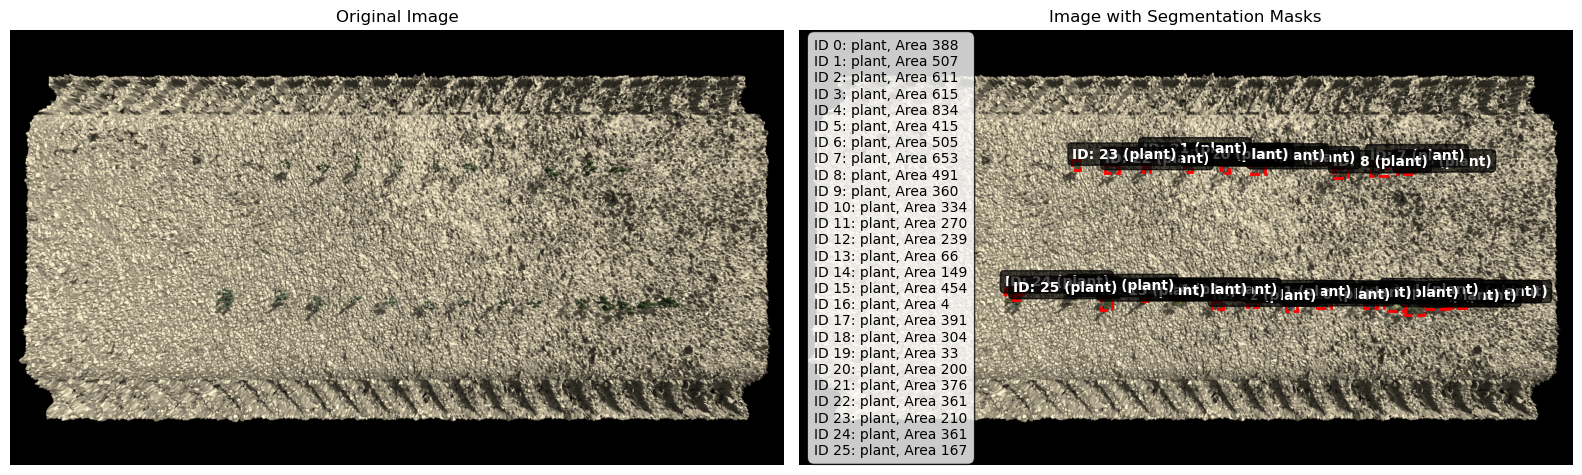

In [38]:
#!/usr/bin/env python3
"""
Visualization script for COCO JSON segmentation masks.
This script displays the generated image alongside the segmentation masks.
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import argparse
import os

def load_classes(classes_path):
    """Load class names from classes.txt file"""
    classes = {}
    if os.path.exists(classes_path):
        with open(classes_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(maxsplit=1)
                if len(parts) == 2:
                    class_id = int(parts[0])
                    class_name = parts[1]
                    classes[class_id] = class_name
    return classes

def load_txt(txt_path, classes):
    """Load bounding boxes from YOLO format txt file"""
    boxes = []
    with open(txt_path, 'r') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line: 
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = parts[0]
            x_c, y_c, w, h = map(float, parts[1:5])
            boxes.append((cls_id, x_c, y_c, w, h))
    return boxes

def draw_boxes(image_path, boxes, classes, out_path=None):
    im = Image.open(image_path).convert("RGBA")
    W, H = im.size
    draw = ImageDraw.Draw(im)
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 14)
    except:
        font = ImageFont.load_default()

    colors = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4"]
    for i, (cls_id, x_c, y_c, w, h) in enumerate(boxes):
        xc = x_c * W
        yc = y_c * H
        bw = w * W
        bh = h * H
        xmin = max(0, xc - bw/2)
        ymin = max(0, yc - bh/2)
        xmax = min(W, xc + bw/2)
        ymax = min(H, yc + bh/2)
        color = colors[int(cls_id) % len(colors)] if cls_id.isdigit() else "#FFFFFF"
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)
        
        # Get class name if available
        class_name = classes.get(int(cls_id), cls_id) if cls_id.isdigit() else cls_id
        label = f"[{i}] {class_name}"
        
        # Use textbbox instead of textsize for newer Pillow versions
        bbox = draw.textbbox((0, 0), label, font=font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]
        draw.rectangle([xmin, ymin - text_h - 4, xmin + text_w + 6, ymin], fill=color)
        draw.text((xmin + 3, ymin - text_h - 2), label, fill="black", font=font)

    if out_path is None:
        base, _ = os.path.splitext(image_path)
        out_path = base + "_bboxes.png"
    
    # Convert RGBA to RGB if saving as JPEG
    if out_path.lower().endswith(('.jpg', '.jpeg')):
        im = im.convert("RGB")
    
    im.save(out_path)
    print("Saved:", out_path)

def load_coco_json(json_path):
    """Load COCO JSON segmentation file"""
    with open(json_path, 'r') as f:
        return json.load(f)

def visualize_segmentation(json_path, output_path=None):
    """
    Visualize the image with segmentation masks overlayed
    
    Args:
        json_path: Path to the COCO JSON file
        output_path: Optional path to save the visualization
    """
    
    # Load JSON first to get image path
    if not os.path.exists(json_path):
        print(f"Error: JSON file not found: {json_path}")
        return
    
    coco_data = load_coco_json(json_path)
    
    # Extract image path from JSON
    if 'images' not in coco_data or len(coco_data['images']) == 0:
        print("Error: No images found in JSON file")
        return
    
    # Get image path from JSON (relative to JSON file location)
    json_dir = os.path.dirname(json_path)
    relative_image_path = coco_data['images'][0]['file_name']
    image_path = os.path.join(json_dir, relative_image_path)
    
    # Normalize the path to handle '../' correctly
    image_path = os.path.normpath(image_path)
    
    # Load image
    if not os.path.exists(image_path):
        print(f"Error: Image file not found: {image_path}")
        return
    
    image = Image.open(image_path)
    
    # Load classes
    classes_path = os.path.join(json_dir, "classes.txt")
    classes = load_classes(classes_path)
    if not classes:
        print(f"Warning: classes.txt not found at {classes_path}")
    
    # Load bounding boxes from txt file
    txt_path = json_path.replace("_labels.json", ".txt")
    if os.path.exists(txt_path):
        boxes = load_txt(txt_path, classes)
        if boxes:
            draw_boxes(image_path, boxes, classes)
        else:
            print("No boxes found in", txt_path)
    else:
        print(f"Warning: TXT file not found: {txt_path}")

    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Show original image
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Show image with segmentation masks
    axes[1].imshow(image)
    axes[1].set_title('Image with Segmentation Masks')
    axes[1].axis('off')
    
    # Create category lookup
    categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
    
    # Colors for different categories (not annotations)
    category_colors = {
        'ground': 'red',
        'bunny': 'blue',
        # Add more colors as needed
    }
    
    # Draw segmentation masks
    for i, annotation in enumerate(coco_data['annotations']):
        # Get category name
        category_id = annotation['category_id']
        category_name = categories.get(category_id, f'Category {category_id}')
        color = category_colors.get(category_name, plt.cm.Set3(i / len(coco_data['annotations'])))
        
        # Get segmentation polygon
        segmentation = annotation['segmentation'][0]  # Assuming single polygon per annotation
        
        # Convert flat list to (x, y) pairs
        points = []
        for j in range(0, len(segmentation), 2):
            points.append([segmentation[j], segmentation[j+1]])
        
        # Create polygon patch
        polygon = Polygon(points, closed=True, alpha=0.4, facecolor=color, edgecolor='black', linewidth=2)
        axes[1].add_patch(polygon)
        
        # Get bounding box
        bbox = annotation['bbox']
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], 
                               linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        axes[1].add_patch(rect)
        
        # Add annotation ID and category as text
        axes[1].text(bbox[0], bbox[1] - 5, f"ID: {annotation['id']} ({category_name})", 
                    color='white', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
    
    # Add legend with annotation info
    legend_text = []
    for i, annotation in enumerate(coco_data['annotations']):
        category_id = annotation['category_id']
        category_name = categories.get(category_id, f'Category {category_id}')
        legend_text.append(f"ID {annotation['id']}: {category_name}, Area {annotation['area']}")
    
    if legend_text:
        axes[1].text(0.02, 0.98, '\n'.join(legend_text), transform=axes[1].transAxes,
                    verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.8))
    
    # Print summary
    print(f"Loaded image: {image.size[0]}x{image.size[1]}")
    print(f"Found {len(coco_data['annotations'])} segmentation masks")
    print(f"Categories: {[cat['name'] for cat in coco_data['categories']]}")
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Visualization saved to: {output_path}")
    
    #plt.show()


visualize_segmentation("build_release/drone_output/plot_21_3_0000_labels.json", "build_release/drone_output/plot_21_3_0000_coco.jpeg")
#visualize_segmentation(str(helios_output_path) + "/plot_0000_labels.json", str(helios_output_path) + "/plot_0000_coco.jpeg")

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm
import copy

# Define the dates
dop = datetime(2025, 5, 27)
dap = datetime(2025, 6, 17) - dop

dataset_path = Path("/home/lion397/GEMINI/heesup/dataset/2025_Davis_Amiga/2025-06-17/Amiga/RGB/AgRowStitch_v0/")
helios_output_path = dataset_path / f"helios_result_dap_{dap.days}"

ds = AmigaStitchDataset(
    root=dataset_path,
    program_path="build_release")
print("Found", len(ds), "images. plot ids:", ds.list_plot_ids())

def process_single_image(idx, dataset_path, helios_output_path, params, dap_days):
    """Process a single image - function for parallel execution"""
    # Create dataset instance in each process
    ds = AmigaStitchDataset(
        root=dataset_path,
        program_path="build_release")
    
    img, meta = ds[idx]
    
    results = ds.localize_plants(idx=idx, min_size=200, use_sam=False, show=False)
    
    # Update params (use copy to avoid shared state issues)
    generated_param_path = ds.generate_params(idx, results, copy.deepcopy(params), age=dap_days)
    
    # Run simulation on the output param
    ds.run_helios(generated_param_path, helios_output_path)
    
    return idx, len(results)

# Parallel execution with 16 workers
num_workers = 16
with ProcessPoolExecutor(max_workers=num_workers) as executor:
    # Submit all tasks
    futures = {
        executor.submit(process_single_image, idx, dataset_path, helios_output_path, params, dap.days): idx 
        for idx in range(len(ds))
    }
    
    # Process completed tasks with progress bar
    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        idx = futures[future]
        try:
            result_idx, num_plants = future.result()
            # Optional: print(f"Processed image {result_idx} with {num_plants} plants")
        except Exception as e:
            print(f"Error processing image {idx}: {e}")